## 1. Dependencies

In [1]:
!pip install -q rdflib langchain-ollama langchain-community langchain-text-splitters chromadb pypdf requests beautifulsoup4 lxml langgraph


## 3. Defining the LLMs for each different task

In [2]:
from langchain_ollama import ChatOllama

# Main model — KG exploration, SPARQL querying, synthesis, feedback
llm = ChatOllama(model="gemma4:12b-mlx", temperature=0.5, num_ctx=4096)

# Router — lightweight classifier, no tools
llm_router = ChatOllama(model="gemma4:12b-mlx", temperature=0, num_ctx=4096)

# RAG model — semantic search distillation
llm_rag_model = ChatOllama(model="gemma4:12b-mlx", temperature=0, num_ctx=4096)


## 4. RAG — Loading the knowledge sources as pdfs and websites

In [3]:
import os, functools, hashlib, shutil
from pathlib import Path
from typing import Iterable, Optional
from urllib.parse import urlparse

import requests
from bs4 import BeautifulSoup

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

# ---------------------------------------------------------------------------
# RAG source configuration
# ---------------------------------------------------------------------------
# Put here any list of report/article URLs you want to index. The example below
# is a World Weather Attribution article URL of the kind required by the workflow.
WEBSITE_URLS = ['https://www.worldweatherattribution.org/southeast-brazil-drought-2014-2015/', 'https://www.worldweatherattribution.org/the-role-of-climate-change-in-the-2015-2017-drought-in-the-western-cape-of-south-africa/', 'https://www.worldweatherattribution.org/ethiopia-drought-2015/', 'https://www.worldweatherattribution.org/uks-storm-desmond-december-2015/', 'https://www.worldweatherattribution.org/chennai-floods-december-2015/', 'https://www.worldweatherattribution.org/kenya-drought-2016/', 'https://www.worldweatherattribution.org/india-heat-wave-2016/', 'https://www.worldweatherattribution.org/european-rainstorms-may-2016/', 'https://www.worldweatherattribution.org/louisiana-downpours-august-2016/', 'https://www.worldweatherattribution.org/somalia-drought-2016-2017/', 'https://www.worldweatherattribution.org/se-europe-cold-january-2017/', 'https://www.worldweatherattribution.org/analysis/cold-spells/', 'https://www.worldweatherattribution.org/extreme-heat-australia-february-2017/', 'https://www.worldweatherattribution.org/european-heat-june-2017/', 'https://www.worldweatherattribution.org/bangladesh-floods-august-2017/', 'https://www.worldweatherattribution.org/hurricane-harvey-august-2017/', 'https://www.worldweatherattribution.org/the-stormy-month-of-january-2018-over-western-europe/', 'https://www.worldweatherattribution.org/a-quick-look-at-the-extreme-rainfall-in-japan/', 'https://www.worldweatherattribution.org/hurricane-florence-september-2018/', 'https://www.worldweatherattribution.org/human-contribution-to-record-breaking-june-2019-heatwave-in-france/', 'https://www.worldweatherattribution.org/rapid-attribution-of-the-extreme-rainfall-in-texas-from-tropical-storm-imelda/', 'https://www.worldweatherattribution.org/climate-change-added-4bn-to-damage-of-japans-typhoon-hagibis/', 'https://www.worldweatherattribution.org/human-induced-climate-change-compounded-by-socio-economic-water-stressors-increased-severity-of-drought-in-syria-iraq-and-iran/', 'https://www.worldweatherattribution.org/human-induced-climate-change-increased-drought-severity-in-southern-horn-of-africa/', 'https://www.worldweatherattribution.org/western-north-american-extreme-heat-virtually-impossible-without-human-caused-climate-change/', 'https://www.worldweatherattribution.org/climate-change-increased-rainfall-associated-with-tropical-cyclones-hitting-highly-vulnerable-communities-in-madagascar-mozambique-malawi/', 'https://www.worldweatherattribution.org/climate-change-made-devastating-early-heat-in-india-and-pakistan-30-times-more-likely/', 'https://www.worldweatherattribution.org/climate-change-exacerbated-rainfall-causing-devastating-flooding-in-eastern-south-africa/', 'https://www.worldweatherattribution.org/climate-change-exacerbated-heavy-rainfall-leading-to-large-scale-flooding-in-highly-vulnerable-communities-in-west-africa/', 'https://www.worldweatherattribution.org/climate-change-increased-heavy-rainfall-hitting-vulnerable-communities-in-eastern-northeast-brazil/', 'https://www.worldweatherattribution.org/climate-change-likely-increased-extreme-monsoon-rainfall-flooding-highly-vulnerable-communities-in-pakistan/', 'https://www.worldweatherattribution.org/without-human-caused-climate-change-temperatures-of-40c-in-the-uk-would-have-been-extremely-unlikely/', 'https://www.worldweatherattribution.org/climate-change-not-el-nino-main-driver-of-exceptional-drought-in-highly-vulnerable-amazon-river-basin/', 'https://www.worldweatherattribution.org/the-role-of-climate-change-in-extreme-rainfall-associated-with-cyclone-gabrielle-over-aotearoa-new-zealands-east-coast/', 'https://www.worldweatherattribution.org/climate-change-more-than-doubled-the-likelihood-of-extreme-fire-weather-conditions-in-eastern-canada/', 'https://www.worldweatherattribution.org/limited-net-role-for-climate-change-in-heavy-spring-rainfall-in-emilia-romagna/', 'https://www.worldweatherattribution.org/limited-data-prevent-assessment-of-role-of-climate-change-in-deadly-floods-affecting-highly-vulnerable-communities-around-lake-kivu/', 'https://www.worldweatherattribution.org/extreme-heat-in-north-america-europe-and-china-in-july-2023-made-much-more-likely-by-climate-change/', 'https://www.worldweatherattribution.org/climate-change-indian-ocean-dipole-compounding-natural-hazards-and-high-vulnerability-increased-severity-of-flooding-in-the-horn-of-africa/', 'https://www.worldweatherattribution.org/climate-change-increased-heavy-precipitation-associated-with-impactful-storm-bettina-over-black-sea/', 'https://www.worldweatherattribution.org/el-nino-key-driver-of-drought-in-highly-vulnerable-southern-african-countries/', 'https://www.worldweatherattribution.org/reducing-vulnerability-and-improved-land-management-needed-with-increasing-heavy-rainfall-in-mindanao-island-southern-philippines-2/', 'https://www.worldweatherattribution.org/despite-known-coastal-cooling-trend-risk-of-deadly-wildfires-in-central-chile-increasing-with-changing-land-management-in-a-warming-climate/', 'https://www.worldweatherattribution.org/urban-planning-at-the-heart-of-increasingly-severe-east-african-flood-impacts-in-a-warming-world/', 'https://www.worldweatherattribution.org/increasing-april-may-rainfall-el-nino-and-high-vulnerability-behind-deadly-flooding-in-afghanistan-pakistan-and-iran/', 'https://www.worldweatherattribution.org/heavy-precipitation-hitting-vulnerable-communities-in-the-uae-and-oman-becoming-an-increasing-threat-as-the-climate-warms/', 'https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/', 'https://www.worldweatherattribution.org/mixed-rainfall-trends-highlight-the-importance-of-climate-adaptation-in-coastal-new-south-wales/', 'https://www.worldweatherattribution.org/extreme-heat-killing-more-than-100-people-in-mexico-hotter-and-much-more-likely-due-to-climate-change/', 'https://www.worldweatherattribution.org/conflict-poverty-and-water-management-issues-exposing-vulnerable-communities-in-africa-to-extreme-floods-that-are-now-common-events-because-of-climate-change/', 'https://www.worldweatherattribution.org/deadly-mediterranean-heatwave-would-not-have-occurred-without-human-induced-climate-change/']

# Optional local PDFs. Leave empty if the RAG knowledge base should be built only
# from URLs.
PDF_PATHS = []

# Chroma root directory. A source-specific subdirectory is created automatically,
# so changing WEBSITE_URLS/PDF_PATHS builds or loads the correct vector DB instead
# of silently reusing an index created for a different source list.
_CHROMA_ROOT = str(Path.home() / "Desktop" / "climate_rag_db")

# Set to True when you want to force a fresh crawl/re-index of the configured URLs.
_FORCE_REBUILD_RAG = False

_HTTP_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; ClimateRAGBot/1.0; "
        "+https://www.worldweatherattribution.org/)"
    )
}


def _normalise_urls(urls: Iterable[str]) -> list[str]:
    """Validate, strip and de-duplicate URL strings while preserving order."""
    seen = set()
    clean_urls = []
    for raw_url in urls:
        url = str(raw_url).strip()
        if not url:
            continue
        parsed = urlparse(url)
        if parsed.scheme not in {"http", "https"} or not parsed.netloc:
            raise ValueError(f"Invalid URL: {raw_url!r}")
        if url not in seen:
            seen.add(url)
            clean_urls.append(url)
    return clean_urls


def configure_rag_sources(
    urls: Optional[Iterable[str]] = None,
    pdf_paths: Optional[Iterable[str]] = None,
    *,
    force_rebuild: bool = False,
) -> None:
    """Update the RAG knowledge-base sources and clear the retriever cache.

    Example:
        configure_rag_sources([
            "https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/",
            "https://www.worldweatherattribution.org/another-report-url/",
        ], force_rebuild=True)

    Run this before invoking the graph if you want to index a different list of
    URLs without editing the notebook cell itself.
    """
    global WEBSITE_URLS, PDF_PATHS, _FORCE_REBUILD_RAG
    if urls is not None:
        WEBSITE_URLS = _normalise_urls(urls)
    if pdf_paths is not None:
        PDF_PATHS = [str(Path(p).expanduser()) for p in pdf_paths if str(p).strip()]
    _FORCE_REBUILD_RAG = bool(force_rebuild)
    _get_retriever.cache_clear()


def _source_signature() -> str:
    """Return a stable hash for the currently configured source list."""
    payload = "\n".join(["URL:" + u for u in _normalise_urls(WEBSITE_URLS)] +
                        ["PDF:" + str(Path(p).expanduser()) for p in PDF_PATHS])
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]


def _rag_chroma_dir() -> str:
    return str(Path(_CHROMA_ROOT) / _source_signature())


def _extract_main_text_from_html(html: str, url: str) -> tuple[str, str]:
    """Extract readable article text from a webpage, with WWA-style pages in mind."""
    soup = BeautifulSoup(html, "lxml")

    for tag in soup(["script", "style", "noscript", "svg", "form", "header", "footer", "nav"]):
        tag.decompose()

    title = ""
    if soup.title and soup.title.string:
        title = soup.title.string.strip()

    # Prefer article/main content. World Weather Attribution report pages normally
    # expose the useful text inside article/main-like containers.
    main = soup.find("article") or soup.find("main")
    if main is None:
        main = soup.find("div", class_=lambda c: c and any(
            token in " ".join(c if isinstance(c, list) else [c]).lower()
            for token in ["content", "entry", "post", "article"]
        ))
    if main is None:
        main = soup.body or soup

    # Remove common non-content elements that may still be nested in the main area.
    for tag in main.find_all(["aside", "button", "form"]):
        tag.decompose()

    parts = []
    for node in main.find_all(["h1", "h2", "h3", "p", "li", "blockquote", "figcaption"]):
        text = " ".join(node.get_text(" ", strip=True).split())
        if len(text) >= 25:
            parts.append(text)

    text = "\n".join(parts)
    return title, text


def _load_url(url: str) -> Document:
    """Load one URL as a LangChain Document with source metadata."""
    try:
        response = requests.get(url, headers=_HTTP_HEADERS, timeout=30)
        response.raise_for_status()
        title, text = _extract_main_text_from_html(response.text, url)
        if len(text) < 500:
            # Fallback to LangChain's generic loader if custom extraction is too thin.
            docs = WebBaseLoader(url).load()
            if docs and docs[0].page_content.strip():
                doc = docs[0]
                doc.metadata.setdefault("source", url)
                doc.metadata.setdefault("title", title or url)
                return doc
            raise ValueError("extracted text was too short")
        return Document(
            page_content=f"Title: {title}\nURL: {url}\n\n{text}",
            metadata={"source": url, "title": title, "source_type": "webpage"},
        )
    except Exception as exc:
        raise RuntimeError(f"Failed to load {url}: {exc}") from exc


def _load_configured_documents() -> list[Document]:
    """Load all configured PDFs and webpages into LangChain Documents."""
    all_docs = []

    for p in PDF_PATHS:
        path = str(Path(p).expanduser())
        if os.path.exists(path):
            pdf_docs = PyPDFLoader(path).load()
            for d in pdf_docs:
                d.metadata.setdefault("source", path)
                d.metadata.setdefault("source_type", "pdf")
            all_docs.extend(pdf_docs)
        else:
            print(f"[RAG] WARNING: {path} not found; skipping PDF.")

    for url in _normalise_urls(WEBSITE_URLS):
        try:
            doc = _load_url(url)
            all_docs.append(doc)
            print(f"[RAG] Loaded URL: {url} ({len(doc.page_content):,} characters)")
        except Exception as exc:
            print(f"[RAG] WARNING: {exc}")

    if not all_docs:
        raise ValueError("No RAG documents were loaded. Check WEBSITE_URLS/PDF_PATHS and network access.")
    return all_docs


@functools.lru_cache(maxsize=1)
def _get_retriever():
    embeddings = OllamaEmbeddings(model="nomic-embed-text")
    chroma_dir = _rag_chroma_dir()

    if _FORCE_REBUILD_RAG and os.path.exists(chroma_dir):
        print(f"[RAG] Force rebuild requested; deleting {chroma_dir}")
        shutil.rmtree(chroma_dir)

    if os.path.exists(chroma_dir) and os.listdir(chroma_dir):
        print(f"[RAG] Loading existing Chroma DB for source set {_source_signature()}...")
        return Chroma(
            persist_directory=chroma_dir,
            embedding_function=embeddings,
        ).as_retriever(search_type="mmr", search_kwargs={"k": 5, "fetch_k": 20})

    print(f"[RAG] Building Chroma DB for {len(WEBSITE_URLS)} URL(s) and {len(PDF_PATHS)} PDF(s)...")
    all_docs = _load_configured_documents()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1200,
        chunk_overlap=180,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    splits = splitter.split_documents(all_docs)
    print(f"[RAG] {len(all_docs)} source document(s) -> {len(splits)} chunk(s)")

    vs = Chroma.from_documents(splits, embeddings, persist_directory=chroma_dir)
    if hasattr(vs, "persist"):
        vs.persist()
    return vs.as_retriever(search_type="mmr", search_kwargs={"k": 5, "fetch_k": 20})


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
len(WEBSITE_URLS)

51

## 5. Defining the tools as functions

In [5]:
from langchain.tools import tool

# ── RAG tool ──────────────────────────────────────────────────────────────

@tool
def semantic_search(question: str) -> str:
    """Semantic search over the configured URL/PDF RAG knowledge base."""
    try:
        docs = _get_retriever().invoke(question)
        if not docs:
            return "No relevant documents found."
        return "\n\n".join(
            f"SOURCE: {d.metadata.get('source', '?')}\n"
            f"TITLE: {d.metadata.get('title', '')}\n"
            f"PASSAGE:\n{d.page_content}"
            for d in docs
        )
    except Exception as e:
        return f"Error: {e}"


## 6. State, system prompts and tool bindings

In [6]:
from typing import Literal
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

MAX_RAG_CALLS = 2   # max semantic_search calls inside rag loop

RAG_SYS = SystemMessage(content=f"""
You are a RAG agent. Only tool: semantic_search.
Call semantic_search at most {MAX_RAG_CALLS} time(s). Use a specific,
targeted query; do not repeat with near-identical queries.
Retrieve relevant passages from the configured URL/PDF vector database.
When summarising, cite the source URL(s) returned by semantic_search and
separate report evidence from your own reasoning.
""")

class AgentState(MessagesState):
    rag_result:      str
    final_answer:    str
    rag_call_count:  int

rag_tools = [semantic_search]
llm_rag = llm_rag_model.bind_tools(rag_tools)


## 7. Defining the functions in each graph node

In [7]:
import time
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, ToolMessage

RAG_HISTORY_WINDOW = 4

def _last_ai(msgs):
    """Most recent non-tool-calling AI message content."""
    return next((m.content for m in reversed(msgs)
                 if isinstance(m, AIMessage) and m.content
                 and not getattr(m, "tool_calls", None)), "")

def _invoke(llm_bound, msgs, retries=3, wait=5):
    """Retry wrapper for transient cloud errors."""
    for i in range(retries):
        try:
            return llm_bound.invoke(msgs)
        except Exception as e:
            if i == retries - 1:
                raise
            print(f"[Retry {i+1}/{retries}] {e} — waiting {wait}s...")
            time.sleep(wait)

# ── RAG ───────────────────────────────────────────────────────────────────

def rag_agent_node(state):
    """Deterministic RAG retrieval.

    This node calls semantic_search directly once, then asks the LLM only to
    summarize the retrieved passages.
    """
    question = state["messages"][0].content
    retrieved = semantic_search.invoke({"question": question})
    prompt = (
        f"Question: {question}\n\n"
        f"Retrieved passages from the configured URL/PDF vector database:\n{retrieved}\n\n"
        "Summarize the RAG evidence. Cite the source URL(s) present in the retrieved passages. "
        "Separate report evidence from your own reasoning, and say explicitly if the retrieved passages do not answer the question."
    )

    r = _invoke(
        llm_rag_model,
        [
            SystemMessage(content="You summarize already-retrieved RAG evidence. Do not call tools."),
            HumanMessage(content=prompt),
        ],
    )

    new_count = state.get("rag_call_count", 0) + 1
    print(f"[RAG] deterministic retrieval completed in {new_count} pass(es)")
    return {
        "messages": [r],
        "rag_call_count": new_count,
    }

def rag_tools_condition(state):
    last = state["messages"][-1]
    calls = state.get("rag_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_RAG_CALLS:
        return "rag_tools"
    if calls >= MAX_RAG_CALLS:
        print(f"[RAG] hit cap ({MAX_RAG_CALLS} calls) — forcing store_rag")
    return "after_rag"

def store_rag_result(state):
    result = _last_ai(state["messages"]) or "No RAG answer."
    print(f"[RAG] done in {state.get('rag_call_count',0)} call(s): {result[:100]}...")
    return {"rag_result": result}

# ── Synthesizer ───────────────────────────────────────────────────────────

SYNTH_SYS = """You must answer using only the evidence provided from the RAG component.

Return only valid JSON with the following fields:

{
  "short_answer": string,
  "answer": string,
  "kg_evidence": string,
  "rag_evidence": string,
  "context": string,
  "sources_used": array of strings,
  "confidence": "high" | "medium" | "low"
}

Rules:
- The short_answer must be the shortest factual answer possible.
- If the question asks for a number, date, country, event ID, disaster type, or yes/no answer, short_answer must contain only that value.
- The answer field may contain one or two explanatory sentences.
- The context field must contain the retrieved information used to answer the question.
- Do not add facts not supported by the RAG evidence.
- Keep kg_evidence as an empty string.
- Reference RAG-derived facts in rag_evidence, including source URL if available."""

def synthesizer_node(state):
    prompt = (f"Question: {state['messages'][0].content}\n\n"
              f"## RAG result\n{state.get('rag_result','N/A')}")
    r = llm_router.invoke([SystemMessage(content=SYNTH_SYS), HumanMessage(content=prompt)])
    print("[Synthesizer] RAG-only answer generated")
    return {"messages": [r], "final_answer": r.content}


## 8. Build and compile graph

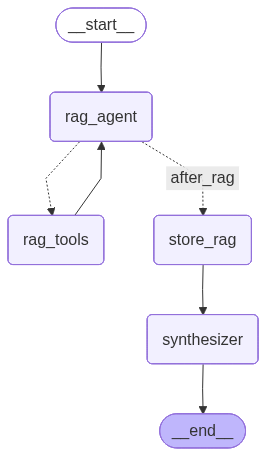

In [8]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

b = StateGraph(AgentState)

b.add_node("rag_agent",       rag_agent_node)
b.add_node("rag_tools",       ToolNode(rag_tools))
b.add_node("store_rag",       store_rag_result)
b.add_node("synthesizer",     synthesizer_node)

b.add_edge(START, "rag_agent")
b.add_conditional_edges("rag_agent", rag_tools_condition, {"rag_tools":"rag_tools", "after_rag":"store_rag"})
b.add_edge("rag_tools", "rag_agent")
b.add_edge("store_rag", "synthesizer")
b.add_edge("synthesizer", END)

react_graph_memory = b.compile(checkpointer=MemorySaver())
display(Image(react_graph_memory.get_graph(xray=True).draw_mermaid_png()))


## 9. Run

In [10]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_expert_validated.xlsx"
QUESTION_COLUMN = "question_new"
OUTPUT_JSON = "borrajas_test/outputs_rag_only_gemma.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_rag_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "rag_result": "",
        "final_answer": "",
        "rag_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
records = []

for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)


# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
output_path.write_text(
    json.dumps(records, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"\nSaved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()



Loaded 39 questions from borrajas_test/benchmark_expert_validated.xlsx column 'question_new'.

[1/39] How many people were killed by flash floods and landslides on 6 and 7 July 2018 in southwestern Japan?
[RAG] Loading existing Chroma DB for source set 30caf3d2651a...


/var/folders/m5/_gg_c8dx3_7cl1gy0wn_kn6r0000gn/T/ipykernel_1552/4089925174.py:194: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(


[RAG] deterministic retrieval completed in 1 pass(es)
[RAG] done in 1 call(s): **Report Evidence**
On 6 and 7 July 2018, torrential rains in southwestern Japan—specifically around...
[Synthesizer] RAG-only answer generated

[2/39] What was maximum daily precipitation recorded at Iizuka station during 6 July 2018?
[RAG] deterministic retrieval completed in 1 pass(es)
[RAG] done in 1 call(s): The maximum daily precipitation recorded at Iizuka station during the period of 6 and 7 July 2018 wa...
[Synthesizer] RAG-only answer generated

[3/39] What agricultural crops suffered severe frost damage in central France in 2021?
[RAG] deterministic retrieval completed in 1 pass(es)
[RAG] done in 1 call(s): Based on the retrieved passages, the agricultural crops that suffered large-scale frost damage in ce...
[Synthesizer] RAG-only answer generated

[4/39] What atmospheric condition contributed to extremely cold winter temperatures in Fennoscandia during early January 2024?
[RAG] deterministic ret

,source_row_index,question,short_answer,confidence,status
0,0,How many people were killed by flash floods an...,At least 200,high,ok
1,1,What was maximum daily precipitation recorded ...,338 mm/dy,high,ok
2,2,What agricultural crops suffered severe frost ...,Grapevines and fruit trees,high,ok
3,3,What atmospheric condition contributed to extr...,Lingering anticyclone,high,ok
4,4,What was the temperature anomaly during the 20...,Over 18ºF (10ºC) colder,high,ok


In [ ]:
print("\n=== CONVERSATION ===")
for m in result["messages"]:
    m.pretty_print()

In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_Fernando_only.xlsx"
QUESTION_COLUMN = "question_new"
OUTPUT_JSON = "borrajas_test/outputs_rag_only.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_rag_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "rag_result": "",
        "final_answer": "",
        "rag_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
records = []

for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)


# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
output_path.write_text(
    json.dumps(records, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"\nSaved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()



In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_Fernando_only.xlsx"
QUESTION_COLUMN = "question_new"
OUTPUT_JSON = "borrajas_test/outputs_rag_only_gemma.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_rag_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "rag_result": "",
        "final_answer": "",
        "rag_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
tmp_output_path = output_path.with_suffix(output_path.suffix + ".tmp")

# Resume from existing output if present.
# This avoids re-running questions that were already saved before an interruption.
if output_path.exists():
    records = json.loads(output_path.read_text(encoding="utf-8"))
    completed_source_rows = {
        record.get("source_row_index")
        for record in records
        if record.get("status") == "ok"
    }
    print(f"Resuming from {output_path}. Found {len(records)} saved records.")
else:
    records = []
    completed_source_rows = set()


def save_records_incrementally(records, output_path, tmp_output_path):
    """Atomically save current records to JSON after each processed question."""
    tmp_output_path.write_text(
        json.dumps(records, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    tmp_output_path.replace(output_path)


for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    if source_row_index in completed_source_rows:
        print(f"\n[{i + 1}/{len(work_df)}] Skipping already completed row {source_row_index}")
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)

    # Save immediately after every answer or error.
    save_records_incrementally(records, output_path, tmp_output_path)
    print(f"Saved progress: {len(records)} records to {output_path.resolve()}")


print(f"\nFinished. Saved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()
